In [13]:
import os
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sys
from pathlib import Path
import tempfile
import urllib.request # needed for geqdsk import
import netCDF4 as nc # OMFIT profile files are netCDF
ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))
# from src.profiles_loop_solve import profiles_loop_solve
from src.profiles_loop_solve_epednn_neped_scan import profiles_loop_solve
from src.load_equil import initialize_inputs

tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_isoflux, read_eqdsk

from examples.device_prediction.helper_functions import read_sparcpublic_profiles, psi_n_and_rho_psi, build_manual_profs, calc_pressure_profile, _print_profile_summary, read_popcon, _to_watts


In [14]:
equil_num = 1
output_dir = f'DIIIDSnyder_freeparam_noloop'
Path(output_dir).mkdir(parents=True, exist_ok=True)



# Equilibria parameters
geqdsk_dir = Path('/mnt/homes_global/jal2351/software/sc_inputs/gHighPerfHMode')
pfile_dir = Path('/mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode')
kprof_loc = 'OMFITnc'
equil_num_total = len(list(pfile_dir.glob('*.cdf')))
if equil_num is None:
    equil_num = equil_num_total
print(f'Number of equilibria found: {equil_num_total}')
print(f'Number of equilibria to process: {equil_num}')
equilibria = initialize_inputs(equil_num, geqdsk_dir, pfile_dir, p_filetype='OMFITnc', select_equil="144515.04108") # Load in equilibria


# ── Heating power ────────────────────────────────────────────────────────────
# The DIII-D inputs carry NO heating power: the EFIT g-files have no slot for it
# and the OMFIT IDA netCDFs hold only kinetic/geometric profiles. Until per-shot
# P_NBI/P_ECH are pulled from MDSplus, use one representative value for the set.
#
# P_HEAT_TOT below is a ballpark for this HighPerfHMode database, obtained by
# integrating W_th = 3/2 * int (p_e + p_ion) dV from these very files and
# inverting IPB98(y,2) at H98 = 1: median ~7.3 MW (quartiles ~3.6-15 MW) over
# the 300 cases. Replace with measured PINJ + P_ECH per shot when available.
P_HEAT_TOT = 7.3e6      # W, total (NBI + ECH + Ohmic) heating, set-representative
ELECTRON_FRAC = 0.5     # Saarelma et al. take ~half the heating as the electron channel

# Fallback Zeff for the two files that carry no Zeff variable
# (IDA_125732_3.45_3.55_.cdf, IDA_128578_3.6_3.7_.cdf). 1.8 is the median of
# the profile-mean Zeff over the 300 files that do have it.
ZEFF_DEFAULT = 1.8
ZEFF_PSI_N = 0.95       # evaluate Zeff at the pedestal top, not on axis


def read_omfitnc_zeff(kprof_fp, psi_eval=ZEFF_PSI_N, default=ZEFF_DEFAULT):
    """Zeff at psi_N = psi_eval from an OMFIT IDA netCDF, averaged over its
    time slices. Returns `default` if the file has no usable Zeff."""
    with nc.Dataset(kprof_fp) as f:
        if 'Zeff' not in f.variables:
            print(f'  Zeff missing in {Path(kprof_fp).name}, using {default}')
            return float(default)
        z = np.ma.filled(f.variables['Zeff'][:], np.nan)   # (time, psi_n)
        psi = np.asarray(f.variables['psi_n'][:])
    z_t = np.nanmean(z, axis=0)
    good = np.isfinite(z_t)
    if not good.any():
        print(f'  Zeff all-NaN in {Path(kprof_fp).name}, using {default}')
        return float(default)
    return float(np.interp(psi_eval, psi[good], z_t[good]))


def read_omfitnc_profiles(kprof_fp):
    """Input kinetic profiles from an OMFIT IDA netCDF, time-averaged, in the
    layout calc_pressure_profile expects (psi_N_ne/psi_N_Te + SI ne + keV Te).

    This is the DIII-D analogue of the SPARC `manual_profs`: it is what the
    solver is fed, so the experimental pedestal pressure is computed from the
    same profiles the model saw. The IDA files carry no main-ion temperature or
    density (only the carbon channels, which are not the main ions), so Ti and
    ni are left out and calc_pressure_profile takes Ti = Te, ni = ne, i.e.
    p = 2*ne*Te.
    """
    with nc.Dataset(kprof_fp) as f:
        psi = np.asarray(f.variables['psi_n'][:], dtype=float)

        def _avg(name):
            if name not in f.variables:
                return None, ''
            var = f.variables[name]
            a = np.ma.filled(var[:], np.nan).astype(float)
            if a.ndim > 1:                      # average over the time axis
                a = np.nanmean(a, axis=0)
            return a, str(getattr(var, 'unit', '')).lower()

        ne, ne_unit = _avg('n_e')
        Te, Te_unit = _avg('T_e')

    if ne is None or Te is None:
        raise KeyError(f'{Path(kprof_fp).name} has no n_e/T_e')

    # IDA files store T in eV and n_e in m^-3; convert T to keV like the solver.
    def _to_keV(t, unit):
        if t is None:
            return None
        if unit in ('ev', 'electron volt', 'electron-volt'):
            return t / 1e3
        if unit in ('kev',):
            return t
        return t / 1e3 if np.nanmax(np.abs(t)) > 100 else t

    Te = _to_keV(Te, Te_unit)
    if ne_unit in ('10^19/m^3', '10^19 m^-3'):
        ne = ne * 1e19
    elif ne_unit in ('10^20/m^3', '10^20 m^-3'):
        ne = ne * 1e20

    # Drop points where any needed channel is NaN, keep the grid monotonic.
    good = np.isfinite(psi) & np.isfinite(ne) & np.isfinite(Te)
    if not good.any():
        raise ValueError(f'{Path(kprof_fp).name} has no finite ne/Te points')

    profiles = {
        'psi_N_ne': psi[good],
        'ne': ne[good],            # m^-3
        'psi_N_Te': psi[good],
        'Te': Te[good],            # keV
        'units': {'ne': 'm^-3', 'Te': 'keV'},
    }
    return profiles


Number of equilibria found: 302
Number of equilibria to process: 1
Equilibrium found without match
Equilibrium found without match
Equilibrium found without match
Selected 1 user-specified g/OMFITnc file pairs:
  g: /mnt/homes_global/jal2351/software/sc_inputs/gHighPerfHMode/g144515.04108
  p: /mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode/IDA_144515_4.05_4.15_.cdf


In [21]:
# Scan parameters
x_res = 50
epednn_model = 'EPED1' # 'EPED1' or 'EPED_SPARC'
EPEDNN_core = 'stiff T_e and n_e'
eped_tol_max = 1e-5
eped_iter_max = 1
kbm_treatment = "picard"
kbm_gate_eps = 0.1
picard_gate_mode = "average"
picard_max_it = 50
picard_rtol = 1e-8
picard_relax = 1.0
verbose_EPEDNNloop = True
verbose_sc = False

import itertools

alpha_crits = np.array([2])
nFC_x0s = np.logspace(15, 16.5, 1)
C_KBMs = np.array([0.3])
De_chie_etgs = np.array([0.5])
ncx_x0_ratios = np.linspace(1, 20, 1)

# ne_x0s = [None, 1e20, 2e20] # m^-3, manually specify outer bc for electron density
ne_x0s = [None] # m^-3, manually specify outer bc for electron density

neped_evals = np.array([0.9396])
# Which n_e profile neped is sampled from at each psi_N above:
#   'solved'    -> the Saarelma-Connor solution (self-consistent; at iter 0 it
#                  sits ~40% below the measurement for this case)
#   'reference' -> the input OMFITnc n_e, i.e. the dashed 'Reference n_e' curve
neped_source = 'reference'

scan_total = len(alpha_crits) * len(C_KBMs) * len(De_chie_etgs) * len(nFC_x0s) * len(ncx_x0_ratios) * len(ne_x0s)
print(f'Total number of scans: {scan_total}*{equil_num}')


Total number of scans: 1*1


144515.04108: Zeff = 1.661, P_tot_e = 3.65 MW, pressure: 2*ne*Te


Setting up EPEDNN...
Base model built.
------------------------------------------------
ESCAPE Loop Iter 0
neped fed to EPEDNN: 3.095e19 m^-3 (reference n_e at psi_N = 0.940)
betan: [1.69108503]
Pedestal height: 0.0043132761222557416 MPa, Pedestal width: 0.03888818759339635 (psi_N)
Setting up EPEDNN...


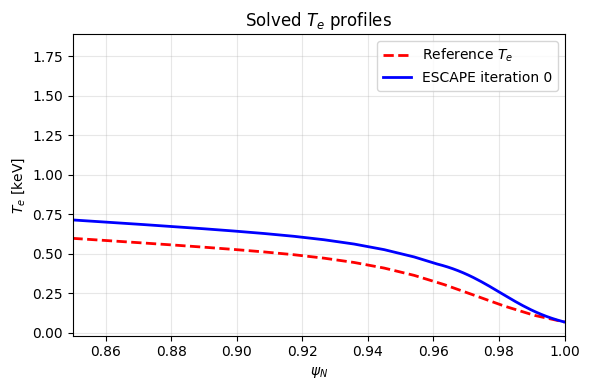

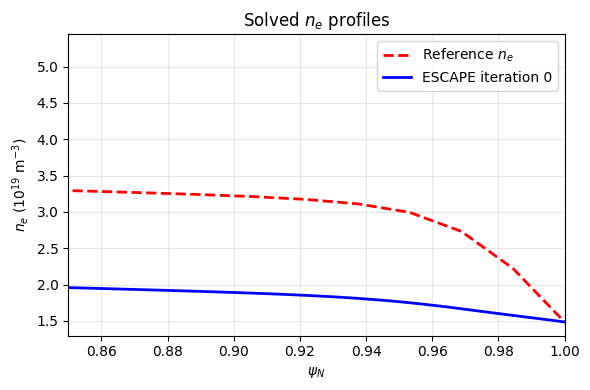

Scan 1 of 1 completed


In [22]:
for mhd_fp, kprof_fp in equilibria:
    for neped_eval in neped_evals:
        equil_tag = Path(mhd_fp).name[1:]
        out_path = Path(output_dir) / equil_tag
        out_path.mkdir(parents=True, exist_ok=True)

        # Zeff is a profile in the OMFIT netCDF, so take it per equilibrium.
        Zeff = read_omfitnc_zeff(kprof_fp)  # dimensionless, at psi_N = ZEFF_PSI_N

        # Input profiles the solver is fed, kept so out_dict['profiles'] and the
        # experimental pedestal pressure both come from the same source.
        profiles = read_omfitnc_profiles(kprof_fp)
        psi_N_p, p_Pa, p_mode = calc_pressure_profile(profiles)

        # P_tot_e: heating power to electrons [W]. No per-shot power in the inputs,
        # so apply the set-representative estimate (see P_HEAT_TOT above).
        P_tot_e = P_HEAT_TOT * ELECTRON_FRAC

        print(f'{equil_tag}: Zeff = {Zeff:.3f}, P_tot_e = {P_tot_e/1e6:.2f} MW, pressure: {p_mode}')

        out_dir_ref = Path(out_path)

        j=0
        for ne_x0 in ne_x0s:
            i=0
            for combo in itertools.product(alpha_crits, C_KBMs, De_chie_etgs, nFC_x0s, ncx_x0_ratios):
                free_params = {
                    'alpha_crit': combo[0],
                    'C_KBM': combo[1],
                    'De_chie_etg': combo[2],
                    'nFC_x0': combo[3],
                    'ncx_x0_ratio': combo[4]
                }

                out_dir = out_dir_ref / Path(f'neouter{j}_fp{i}_neped{neped_eval:.3f}_{neped_source}')
                out_dir.mkdir(parents=True, exist_ok=True)


                try:
                    ped_wid, ped_h_out, sol = profiles_loop_solve(
                        MHD_FP = mhd_fp,
                        KPROF_FP = kprof_fp,
                        kprof_loc = 'OMFITnc',
                        P_tot_e = P_tot_e,
                        species = 'D',
                        Z_eff = Zeff,
                        out_dir = out_dir,
                        x_res = x_res,
                        ne_x0 = ne_x0,
                        free_params = free_params,
                        eped_tol_max = eped_tol_max,
                        eped_iter_max = eped_iter_max,
                        kbm_gate_eps = kbm_gate_eps,
                        kbm_treatment = kbm_treatment,
                        picard_gate_mode = picard_gate_mode,
                        picard_max_it = picard_max_it,
                        picard_rtol = picard_rtol,
                        picard_relax = picard_relax,
                        ig = 'manual',
                        epednn_model = epednn_model,
                        EPEDNN_core = EPEDNN_core,
                        epednn_neped_psin_eval = neped_eval,
                        epednn_neped_source = neped_source,
                        verbose = verbose_EPEDNNloop,
                        verbose_sc = verbose_sc,
                    )

                    # Experimental pedestal pressure at psi_N = 1 - ped_wid, from the
                    # input profiles (psi_N_p / p_Pa built once per equilibrium above).
                    psi_ped_top = 1.0 - float(ped_wid)
                    p_at_ped_top = float(np.interp(psi_ped_top, psi_N_p, p_Pa))

                    # Save model output
                    out_dict = {
                        'mhd_fp': mhd_fp,
                        'kprof_fp': kprof_fp,
                        'profiles': profiles,
                        'ESCAPE_ped_h': ped_h_out,
                        'ESCAPE_ped_wid': ped_wid,
                        'experimental_ped_h': p_at_ped_top,
                        'free_params': free_params,
                        'profiles_solved': sol, # profiles
                        'p_mode': p_mode,
                        'Zeff': Zeff,
                        'P_tot_e': P_tot_e,
                        'i': i,
                        'neped_eval': neped_eval,
                        'neped_source': neped_source
                    }
                    np.save(out_dir / 'out_dict.npy', out_dict)
                except Exception as e:
                    out_dict = {'failed': True, 'free_params': free_params, 'error': str(e)}
                    np.save(out_dir / 'failed.npy', out_dict)

                if i%50 == 0:
                    print(f'Scan {i+1} of {scan_total} completed')
                i+=1
            j+=1

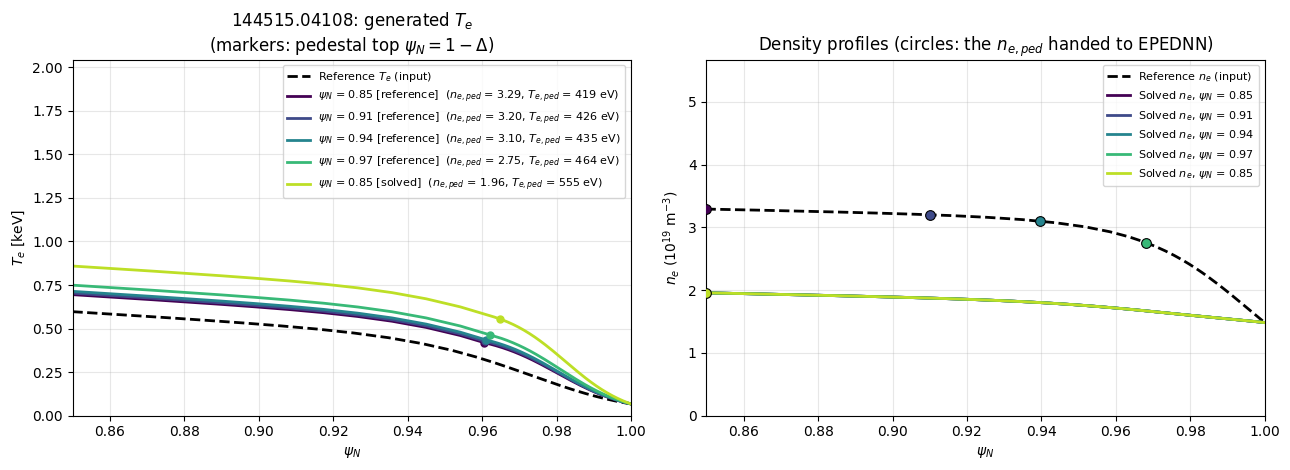

 psiN_neped     source  neped[1e19]  p_ped[kPa]    width  psi_ped  ne(psi_ped)  Te_ped[eV]
      0.850  reference        3.294       4.422   0.0394   0.9606        3.294       419.0
      0.910  reference        3.201       4.374   0.0392   0.9608        3.201       426.4
      0.940  reference        3.095       4.313   0.0389   0.9611        3.095       434.9
      0.968  reference        2.746       4.082   0.0379   0.9621        2.746       464.0
      0.850     solved        1.958       3.483   0.0352   0.9648        1.958       555.0


In [23]:
# ── T_e (and n_e) from the neped scan ───────────────────────────────────────
# Left: the T_e profile profiles_loop_solve generated for each neped_eval.
# Right: the density profiles, with a marker at the psi_N where neped was
# sampled — so it is unambiguous which curve each neped came off of.
import glob

equil_tag = Path(equilibria[0][0]).name[1:]
scan_dirs = sorted(glob.glob(str(Path(output_dir) / equil_tag / 'neouter*_fp*_neped*')))
if not scan_dirs:
    raise FileNotFoundError(
        f'No scan directories under {Path(output_dir) / equil_tag}. '
        f'Run the scan cell above first.'
    )


def _load_run(run_dir):
    """Everything the plots need for one neped_eval, or None if unusable."""
    out_fp = Path(run_dir) / 'out_dict.npy'
    if not out_fp.exists():
        print(f'  skip {Path(run_dir).name}: no out_dict.npy (run failed?)')
        return None
    out = np.load(out_fp, allow_pickle=True).item()
    sol = out['profiles_solved']

    if 'Te_new_keV' not in sol:
        # The loop broke on convergence before generating a new T_e this pass;
        # fall back to the most recent per-iteration file that has one.
        for it_fp in sorted((Path(run_dir) / equil_tag).glob('ne_and_Te_iter_*.npy'),
                            reverse=True):
            cand = np.load(it_fp, allow_pickle=True).item()
            if 'Te_new_keV' in cand:
                sol = cand
                break
        else:
            print(f'  skip {Path(run_dir).name}: no generated T_e stored')
            return None

    psi_ne = np.asarray(sol['psi_N_ne'], dtype=float)
    ne = np.asarray(sol['y'], dtype=float)
    order = np.argsort(psi_ne)
    neped_eval = float(sol.get('epednn_neped_psin_eval', out['neped_eval']))
    source = str(sol.get('epednn_neped_source', out.get('neped_source', 'solved')))

    # What EPEDNN actually received (recorded by the solver); older saves that
    # predate that field fall back to sampling the solved profile.
    if 'neped_epednn_1e19' in sol:
        neped_fed = float(sol['neped_epednn_1e19'])
    else:
        neped_fed = float(np.interp(neped_eval, psi_ne[order], ne[order])) / 1e19

    return dict(
        neped_eval=neped_eval, source=source, neped_fed=neped_fed,
        psi_Te=np.asarray(sol['psi_N_Te_new'], dtype=float),
        Te_keV=np.asarray(sol['Te_new_keV'], dtype=float),
        psi_ne=psi_ne[order], ne=ne[order],
        psi_ped=float(sol['psi_ped']), Te_ped_eV=float(sol['Te_ped_eV']),
        ne_ped_val=float(sol['ne_ped_val']), out=out,
    )


runs = [r for r in (_load_run(d) for d in scan_dirs) if r is not None]
runs.sort(key=lambda r: (r['source'], r['neped_eval']))
if not runs:
    raise RuntimeError('No runs with a stored T_e profile were found.')

colors = plt.cm.viridis(np.linspace(0, 0.9, len(runs)))

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

ref = runs[0]['out']['profiles']
ax.plot(ref['psi_N_Te'], ref['Te'], 'k--', lw=2, label='Reference $T_e$ (input)')
ax2.plot(ref['psi_N_ne'], np.asarray(ref['ne']) / 1e19, 'k--', lw=2,
         label='Reference $n_e$ (input)')

for r, color in zip(runs, colors):
    lbl = (rf"$\psi_N$ = {r['neped_eval']:.2f} [{r['source']}]  "
           rf"($n_{{e,ped}}$ = {r['neped_fed']:.2f}, "
           rf"$T_{{e,ped}}$ = {r['Te_ped_eV']:.0f} eV)")
    ax.plot(r['psi_Te'], r['Te_keV'], lw=2, color=color, label=lbl)
    ax.plot(r['psi_ped'], r['Te_ped_eV'] / 1e3, 'o', ms=5, color=color)

    ax2.plot(r['psi_ne'], r['ne'] / 1e19, lw=2, color=color,
             label=rf"Solved $n_e$, $\psi_N$ = {r['neped_eval']:.2f}")
    # the point that became EPEDNN's neped input
    ax2.plot(r['neped_eval'], r['neped_fed'], 'o', ms=7, color=color,
             mec='k', mew=0.8, zorder=5)

ax.set_xlabel(r'$\psi_N$')
ax.set_ylabel(r'$T_e$ [keV]')
ax.set_title(rf'{equil_tag}: generated $T_e$'
             '\n' r'(markers: pedestal top $\psi_N = 1 - \Delta$)')
ax.set_xlim(0.85, 1.0)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

ax2.set_xlabel(r'$\psi_N$')
ax2.set_ylabel(r'$n_e$ ($10^{19}$ m$^{-3}$)')
ax2.set_title(r'Density profiles (circles: the $n_{e,ped}$ handed to EPEDNN)')
ax2.set_xlim(0.85, 1.0)
ax2.set_ylim(bottom=0)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()

print(f'{"psiN_neped":>11} {"source":>10} {"neped[1e19]":>12} {"p_ped[kPa]":>11} '
      f'{"width":>8} {"psi_ped":>8} {"ne(psi_ped)":>12} {"Te_ped[eV]":>11}')
for r in runs:
    print(f'{r["neped_eval"]:11.3f} {r["source"]:>10} {r["neped_fed"]:12.3f} '
          f'{r["out"]["ESCAPE_ped_h"]*1e3:11.3f} {r["out"]["ESCAPE_ped_wid"]:8.4f} '
          f'{r["psi_ped"]:8.4f} {r["ne_ped_val"]/1e19:12.3f} {r["Te_ped_eV"]:11.1f}')
